<a href="https://colab.research.google.com/github/MennaEzzelarab/NLP_SAG_Mohler/blob/main/short_answer_grading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Short Answer Grading — Automatic Scoring with NLP
> **Dataset:** MohlerASAG &nbsp;|&nbsp; **Task:** Classify student answer quality (0–5) by measuring semantic similarity to the model answer

## 1. Install & Import Dependencies
We use `sentence-transformers` for SBERT embeddings and standard ML libraries for modeling and evaluation.

In [ ]:
!pip install -q datasets sentence-transformers scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## 2. Load & Inspect the Dataset
The MohlerASAG dataset contains student answers, model (desired) answers, and scores from two human graders. We load it and convert to a pandas DataFrame.

In [ ]:
ds = load_dataset('nkazi/MohlerASAG', name='raw', split='open_ended')
df = ds.to_pandas()

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

README.md: 0.00B [00:00, ?B/s]

data/raw-oe-00001.parquet:   0%|          | 0.00/150k [00:00<?, ?B/s]

data/raw-ce-00001.parquet:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

Generating open_ended split:   0%|          | 0/2273 [00:00<?, ? examples/s]

Generating close_ended split:   0%|          | 0/169 [00:00<?, ? examples/s]

Shape: (2273, 7)

Columns: ['id', 'question', 'instructor_answer', 'student_answer', 'score_grader_1', 'score_grader_2', 'score_avg']

First 3 rows:


,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg
0,E01.Q01.A00,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,High risk problems are address in the prototyp...,3.0,4.0,3.5
1,E01.Q01.A01,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To simulate portions of the desired final prod...,5.0,5.0,5.0
2,E01.Q01.A02,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,A prototype program simulates the behaviors of...,3.0,5.0,4.0


In [ ]:
print("Missing values:\n", df.isnull().sum())
print("\nScore (avg) statistics:")
print(df['score_avg'].describe())

Missing values:
 id                   0
question             0
instructor_answer    0
student_answer       0
score_grader_1       0
score_grader_2       0
score_avg            0
dtype: int64

Score (avg) statistics:
count    2273.000000
mean        4.183898
std         1.096598
min         0.000000
25%         3.500000
50%         4.500000
75%         5.000000
max         5.000000
Name: score_avg, dtype: float64


## 3. Exploratory Data Analysis (EDA)
Before modeling, we explore the score distribution, inter-grader agreement, and answer lengths. This informs our preprocessing and evaluation strategy.

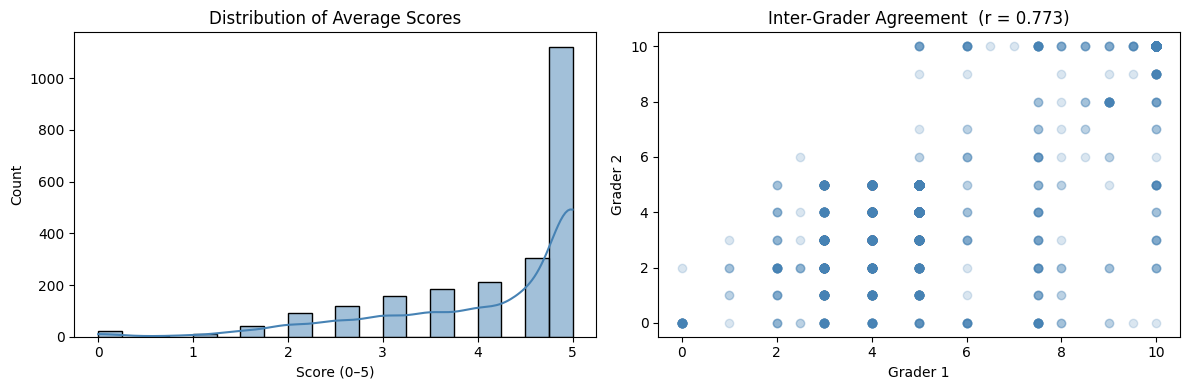

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score distribution
sns.histplot(df['score_avg'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Average Scores')
axes[0].set_xlabel('Score (0–5)')

# Grader agreement
corr, _ = pearsonr(df['score_grader_1'], df['score_grader_2'])
axes[1].scatter(df['score_grader_1'], df['score_grader_2'], alpha=0.2, color='steelblue')
axes[1].set_title(f'Inter-Grader Agreement  (r = {corr:.3f})')
axes[1].set_xlabel('Grader 1')
axes[1].set_ylabel('Grader 2')

plt.tight_layout()
plt.show()

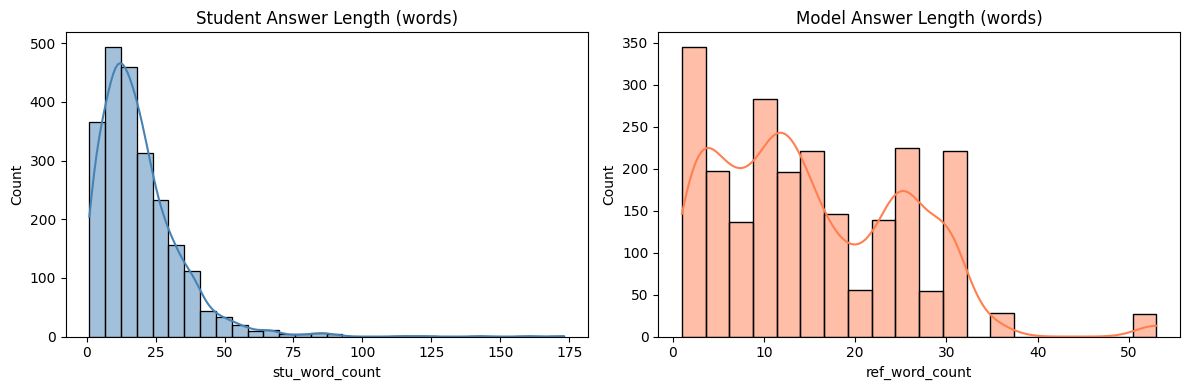

In [ ]:
# Answer length analysis
df['stu_word_count'] = df['student_answer'].str.split().str.len()
df['ref_word_count']  = df['instructor_answer'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['stu_word_count'], bins=30, color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('Student Answer Length (words)')
sns.histplot(df['ref_word_count'], bins=20, color='coral', kde=True, ax=axes[1])
axes[1].set_title('Model Answer Length (words)')
plt.tight_layout()
plt.show()

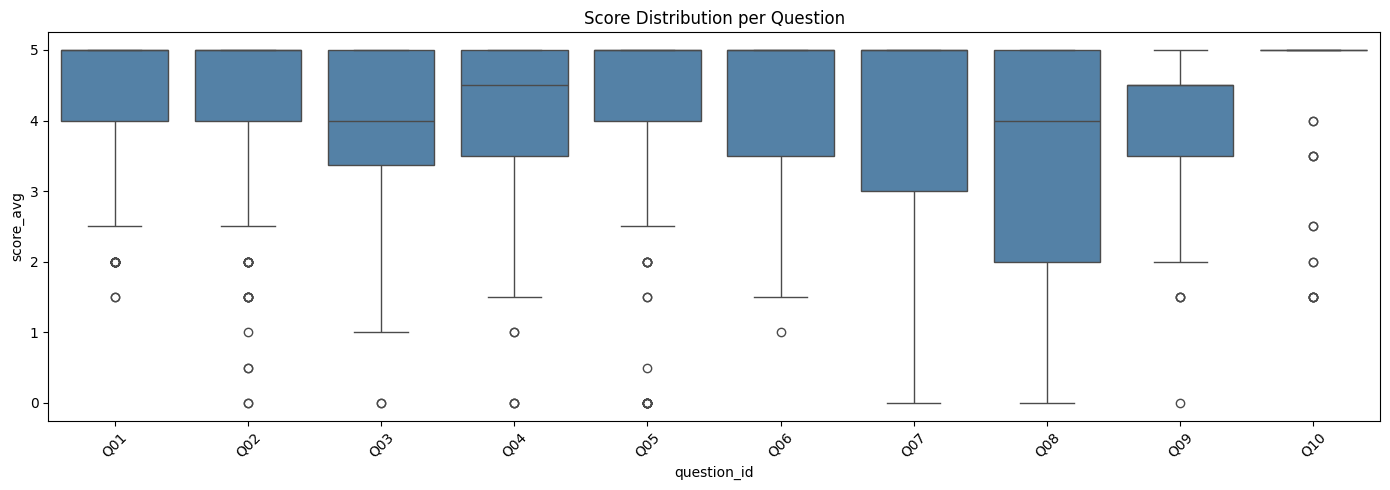

In [ ]:
# Score distribution per question
df['question_id'] = df['id'].str.extract(r'\.(Q\d+)\.')
plt.figure(figsize=(14, 5))
sns.boxplot(x='question_id', y='score_avg', data=df, color='steelblue')
plt.xticks(rotation=45)
plt.title('Score Distribution per Question')
plt.tight_layout()
plt.show()

## 4. Preprocessing
We prepare the target label by rounding the average score to the nearest integer (0–5), giving us 6 classes for classification. We also drop any rows with missing answers.

In [ ]:
# Drop rows with missing text
df = df.dropna(subset=['student_answer', 'instructor_answer', 'score_avg']).reset_index(drop=True)

## 5. Baseline — TF-IDF Cosine Similarity
Before using deep learning, we establish a classical NLP baseline. Each student answer and its corresponding model answer are represented as TF-IDF vectors; cosine similarity gives a score between 0 and 1. This directly captures "common word" overlap as described in the project spec.

In [ ]:
# Fit TF-IDF on all text in the dataset
all_texts = pd.concat([df['student_answer'], df['instructor_answer']]).tolist()
tfidf = TfidfVectorizer(ngram_range=(1, 2), stop_words='english')
tfidf.fit(all_texts)

# Compute per-row cosine similarity
stu_vecs = tfidf.transform(df['student_answer'])
ref_vecs = tfidf.transform(df['instructor_answer'])

tfidf_sim = np.array([
    cosine_similarity(stu_vecs[i], ref_vecs[i])[0][0]
    for i in range(len(df))
])

df['tfidf_similarity'] = tfidf_sim
print(f"TF-IDF similarity — mean: {tfidf_sim.mean():.3f}, std: {tfidf_sim.std():.3f}")

TF-IDF similarity — mean: 0.166, std: 0.219


Pearson r:  0.3579
Spearman r: 0.4821


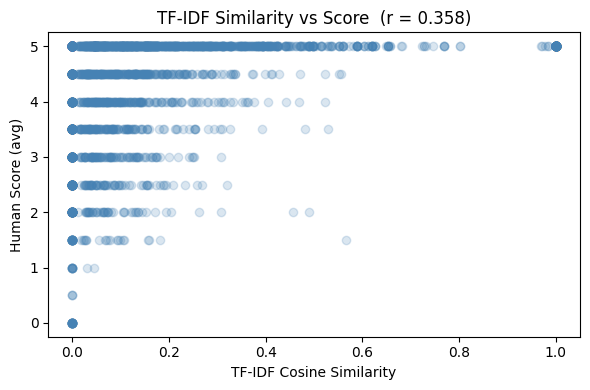

In [ ]:
# Correlation between TF-IDF similarity and human score
r_pearson, _  = pearsonr(df['tfidf_similarity'], df['score_avg'])
r_spearman, _ = spearmanr(df['tfidf_similarity'], df['score_avg'])
print(f"Pearson r:  {r_pearson:.4f}")
print(f"Spearman r: {r_spearman:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(df['tfidf_similarity'], df['score_avg'], alpha=0.2, color='steelblue')
plt.xlabel('TF-IDF Cosine Similarity')
plt.ylabel('Human Score (avg)')
plt.title(f'TF-IDF Similarity vs Score  (r = {r_pearson:.3f})')
plt.tight_layout()
plt.show()

## 6. SBERT Sentence Embeddings
We use a pretrained SBERT transformer model (`all-MiniLM-L6-v2`) to encode both the student answer and the model answer into dense semantic vectors. This captures *meaning*, not just word overlap — a student who paraphrases correctly will still score high.

In [ ]:
sbert = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding student answers...")
stu_embeddings = sbert.encode(df['student_answer'].tolist(), show_progress_bar=True, batch_size=64)

print("Encoding model answers...")
ref_embeddings = sbert.encode(df['instructor_answer'].tolist(), show_progress_bar=True, batch_size=64)

print(f"\nEmbedding shape: {stu_embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding student answers...


Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Encoding model answers...


Batches:   0%|          | 0/36 [00:00<?, ?it/s]


Embedding shape: (2273, 384)


## 7. Feature Engineering
We build a rich feature vector for each answer pair by combining:
- **Cosine similarity** between the two embeddings (1 feature)
- **Element-wise absolute difference** |u − v| (captures what's missing)
- **Element-wise product** u * v (captures what's shared)

This is the standard feature set for sentence-pair classification tasks.

In [ ]:
# Cosine similarity (SBERT)
sbert_sim = np.array([
    cosine_similarity(stu_embeddings[i].reshape(1, -1),
                      ref_embeddings[i].reshape(1, -1))[0][0]
    for i in range(len(df))
])
df['sbert_similarity'] = sbert_sim

diff    = np.abs(stu_embeddings - ref_embeddings)
product = stu_embeddings * ref_embeddings
sim_col = sbert_sim.reshape(-1, 1)
tfidf_col = tfidf_sim.reshape(-1, 1)

X = np.hstack([sim_col, tfidf_col, diff, product])
y = df['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape:         {y.shape}")

Feature matrix shape: (2273, 770)
Labels shape:         (2273,)


SBERT cosine similarity — Pearson r: 0.4927
TF-IDF cosine similarity — Pearson r: 0.3579


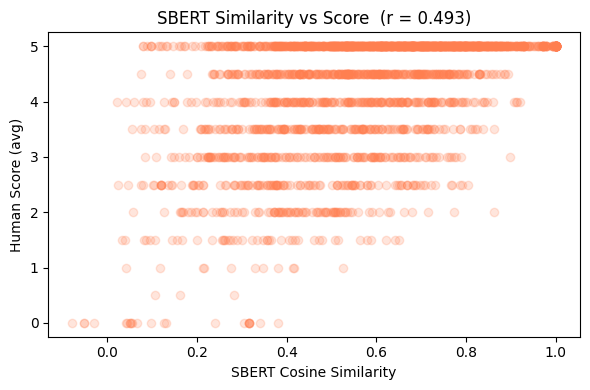

In [ ]:
# Correlation: SBERT similarity vs human score
r_sbert, _ = pearsonr(sbert_sim, df['score_avg'])
print(f"SBERT cosine similarity — Pearson r: {r_sbert:.4f}")
print(f"TF-IDF cosine similarity — Pearson r: {r_pearson:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(sbert_sim, df['score_avg'], alpha=0.2, color='coral')
plt.xlabel('SBERT Cosine Similarity')
plt.ylabel('Human Score (avg)')
plt.title(f'SBERT Similarity vs Score  (r = {r_sbert:.3f})')
plt.tight_layout()
plt.show()